# Detecção de Anomalias em Transações Financeiras

Este projeto utiliza técnicas de machine learning para identificar possíveis fraudes em transações financeiras.

O objetivo é analisar o impacto do desbalanceamento de classes e comparar modelos de classificação, utilizando métricas como precision, recall, F1-score e ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## 1. Carregamento e inspeção dos dados

O dataset utilizado contém transações financeiras classificadas como normais (`Class = 0`) ou fraudulentas (`Class = 1`).

As colunas `V1` até `V28` são variáveis anonimizadas, enquanto `Time` representa o tempo da transação e `Amount` representa o valor da compra.


In [2]:
DATASET_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
)

df = pd.read_csv(DATASET_URL)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Estrutura e qualidade dos dados

Nesta etapa, será verificado o tamanho do dataset, os tipos das colunas e a existência de valores ausentes.

Também será analisada a distribuição da coluna `Class`, pois fraudes representam uma parcela muito pequena das transações.

In [3]:
print("Dimensões do dataset:", df.shape)

print("\nTipos das colunas:")
display(df.dtypes)

print("\nValores ausentes por coluna:")
display(df.isnull().sum())

Dimensões do dataset: (284807, 31)

Tipos das colunas:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Valores ausentes por coluna:


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
class_counts = df["Class"].value_counts()

print("Quantidade de transações por classe:")
display(class_counts)

print("\nProporção de cada classe:")
display(df["Class"].value_counts(normalize=True))

Quantidade de transações por classe:


Class
0    284315
1       492
Name: count, dtype: int64


Proporção de cada classe:


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Distribuição das classes

O gráfico abaixo mostra a diferença entre transações normais e fraudulentas.

Como a classe de fraude é muito menor, a accuracy não será usada sozinha para avaliar os modelos. Serão consideradas principalmente as métricas de precision, recall, F1-score e ROC-AUC.

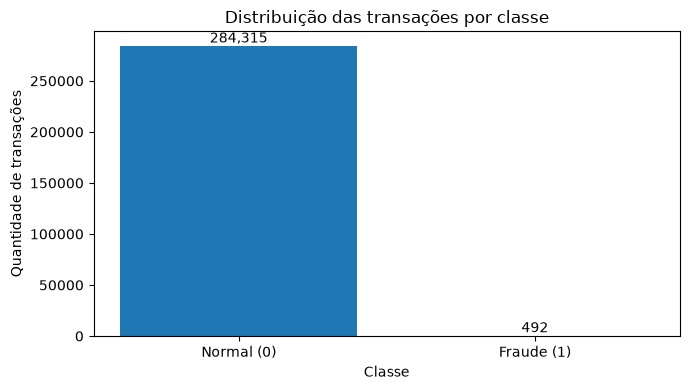

In [5]:
plt.figure(figsize=(7, 4))

plt.bar(
    ["Normal (0)", "Fraude (1)"],
    class_counts.values
)

plt.title("Distribuição das transações por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade de transações")

for index, value in enumerate(class_counts.values):
    plt.text(index, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 3. Preparação dos dados

Nesta etapa, será criada uma versão logarítmica da coluna `Amount` para reduzir o impacto de valores muito altos.

Depois, os dados serão separados em treino e teste. O conjunto de teste ficará reservado para avaliar os modelos em transações que eles não viram durante o treinamento.


In [6]:
df["Amount_log"] = np.log1p(df["Amount"])

df[["Amount", "Amount_log"]].head()

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [7]:
X = df.drop(columns=["Class", "Amount"])
y = df["Class"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (284807, 30)
Formato de y: (284807,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Transações de treino:", X_train.shape[0])
print("Transações de teste:", X_test.shape[0])

print("\nFraudes no treino:")
print(y_train.value_counts())

print("\nFraudes no teste:")
print(y_test.value_counts())

Transações de treino: 199364
Transações de teste: 85443

Fraudes no treino:
Class
0    199020
1       344
Name: count, dtype: int64

Fraudes no teste:
Class
0    85295
1      148
Name: count, dtype: int64


### Padronização das variáveis

As variáveis `Time` e `Amount_log` possuem escalas diferentes das colunas `V1` até `V28`.

A padronização ajuda especialmente a Regressão Logística, evitando que valores maiores tenham influência apenas por causa da escala numérica.


In [9]:
scale_columns = ["Time", "Amount_log"]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

X_train[scale_columns].head()

,Time,Amount_log
249927,1.257992,-0.639152
214082,0.939713,1.125111
106005,-0.528960,2.426709
58619,-0.977583,-0.876241
191638,0.725456,-0.876241


## 4. Modelo baseline: Regressão Logística

A Regressão Logística será utilizada como modelo inicial de classificação.

Ela serve como referência para avaliar se modelos mais avançados conseguem melhorar a identificação de fraudes, principalmente em uma base fortemente desbalanceada.

In [10]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [11]:
print("Relatório de classificação — Regressão Logística\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — Regressão Logística

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.86      0.61      0.71       148

    accuracy                           1.00     85443
   macro avg       0.93      0.80      0.86     85443
weighted avg       1.00      1.00      1.00     85443



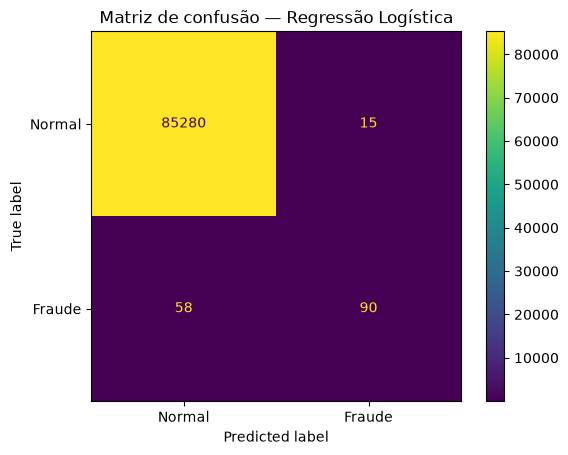

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — Regressão Logística")
plt.show()

### Curva ROC e ROC-AUC

A curva ROC mostra o comportamento do modelo em diferentes limites de decisão.

O ROC-AUC resume essa capacidade em um valor entre 0 e 1. Quanto mais próximo de 1, melhor o modelo consegue diferenciar transações normais de fraudulentas.

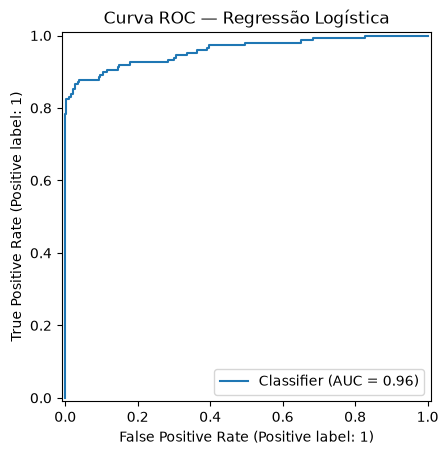

ROC-AUC da Regressão Logística: 0.9586


In [13]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic
)

plt.title("Curva ROC — Regressão Logística")
plt.show()

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print(f"ROC-AUC da Regressão Logística: {roc_auc_logistic:.4f}")

## 5. Ajuste do limite de decisão

Por padrão, o modelo classifica uma transação como fraude quando a probabilidade prevista é maior ou igual a 0,5.

Como fraudes são raras e o custo de não detectá-las pode ser alto, será testado um limite menor, de 0,3. Isso tende a aumentar o recall, mas também pode gerar mais falsos positivos.

In [14]:
threshold = 0.30

y_pred_threshold = (y_prob_logistic >= threshold).astype(int)

print(f"Relatório de classificação — Threshold = {threshold}\n")

print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — Threshold = 0.3

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.79      0.65      0.71       148

    accuracy                           1.00     85443
   macro avg       0.89      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



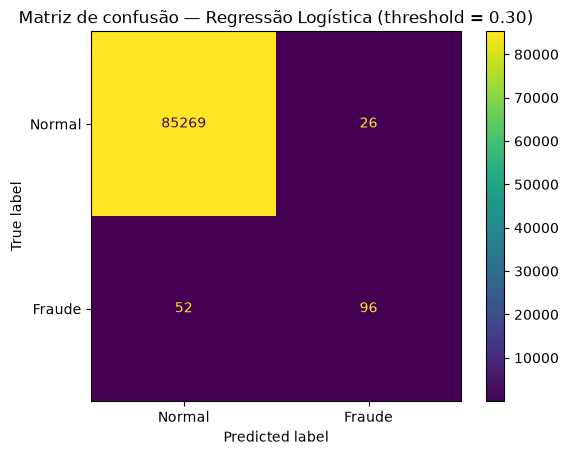

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — Regressão Logística (threshold = 0.30)")
plt.show()

### Comparação dos thresholds

Com o threshold padrão de 0,50, o modelo detectou 90 fraudes e deixou 58 passarem.

Ao reduzir o threshold para 0,30, foram detectadas 96 fraudes, mas aumentou a quantidade de transações normais classificadas incorretamente como fraude.

Isso demonstra o trade-off entre recall e precision: reduzir o limite pode encontrar mais fraudes, mas também aumenta os falsos positivos.

## 6. Random Forest com balanceamento de classes

O Random Forest será utilizado com `class_weight="balanced"` para dar mais importância às transações fraudulentas durante o treinamento.

Essa abordagem não altera os dados de treino, mas ajusta o peso dado à classe minoritária.

In [16]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest treinado com sucesso.")

Random Forest treinado com sucesso.


### Avaliação do Random Forest

O modelo será avaliado com precision, recall, F1-score, matriz de confusão e ROC-AUC.

Como o dataset é desbalanceado, o foco principal será a capacidade de identificar fraudes sem gerar alertas falsos em excesso.

In [17]:
print("Relatório de classificação — Random Forest\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — Random Forest

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.73      0.79      0.76       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.88     85443
weighted avg       1.00      1.00      1.00     85443



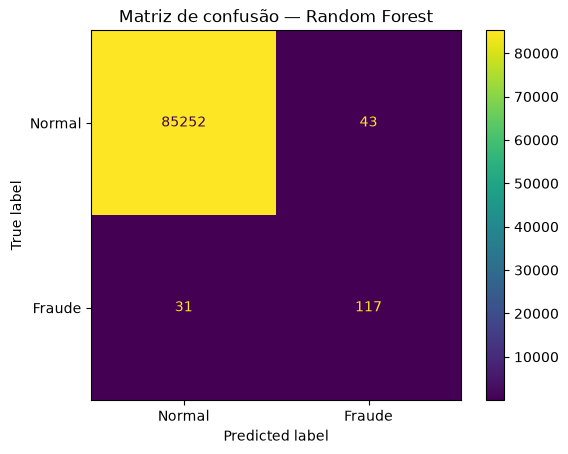

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — Random Forest")
plt.show()

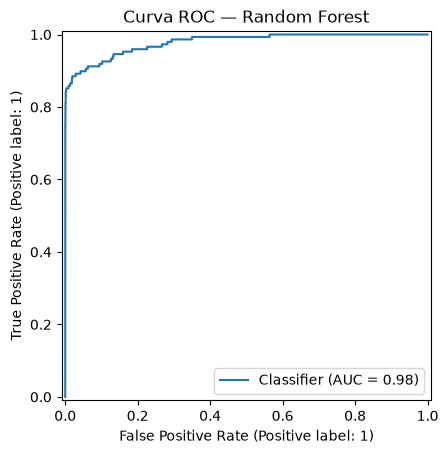

ROC-AUC do Random Forest: 0.9784


In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Curva ROC — Random Forest")
plt.show()

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"ROC-AUC do Random Forest: {roc_auc_rf:.4f}")

## 7. Comparação inicial dos modelos

Nesta etapa, serão comparados os resultados da Regressão Logística com threshold padrão, da Regressão Logística com threshold de 0,30 e do Random Forest com balanceamento de classes.

A análise dará prioridade à identificação de fraudes, especialmente ao recall e à quantidade de falsos negativos.

In [20]:
def get_model_metrics(model_name, predictions, probabilities):
    return {
        "Modelo": model_name,
        "Precision (Fraude)": precision_score(y_test, predictions, zero_division=0),
        "Recall (Fraude)": recall_score(y_test, predictions, zero_division=0),
        "F1-score (Fraude)": f1_score(y_test, predictions, zero_division=0),
        "Fraudes detectadas": int(((y_test == 1) & (predictions == 1)).sum()),
        "Fraudes não detectadas": int(((y_test == 1) & (predictions == 0)).sum()),
        "Falsos positivos": int(((y_test == 0) & (predictions == 1)).sum()),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

In [21]:
comparison_results = pd.DataFrame([
    get_model_metrics(
        "Regressão Logística (0.50)",
        y_pred_logistic,
        y_prob_logistic
    ),
    get_model_metrics(
        "Regressão Logística (0.30)",
        y_pred_threshold,
        y_prob_logistic
    ),
    get_model_metrics(
        "Random Forest",
        y_pred_rf,
        y_prob_rf
    )
])

comparison_results.round(4)

,Modelo,Precision (Fraude),Recall (Fraude),F1-score (Fraude),Fraudes detectadas,Fraudes não detectadas,Falsos positivos,ROC-AUC
0,Regressão Logística (0.50),0.8571,0.6081,0.7115,90,58,15,0.9586
1,Regressão Logística (0.30),0.7869,0.6486,0.7111,96,52,26,0.9586
2,Random Forest,0.7312,0.7905,0.7597,117,31,43,0.9784


## 8. Importância das variáveis

O Random Forest permite verificar quais variáveis tiveram maior influência nas previsões do modelo.

Como as colunas `V1` até `V28` são anonimizadas, essa análise mostra apenas quais variáveis são mais relevantes para o modelo, sem permitir uma interpretação de negócio detalhada.

In [22]:
feature_importance = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importância",
    ascending=False
)

feature_importance.head(10)

,Variável,Importância
14,V14,0.194418
10,V10,0.117180
4,V4,0.112140
12,V12,0.100494
17,V17,0.096676
3,V3,0.066117
11,V11,0.050372
16,V16,0.047597
2,V2,0.038214
9,V9,0.025522


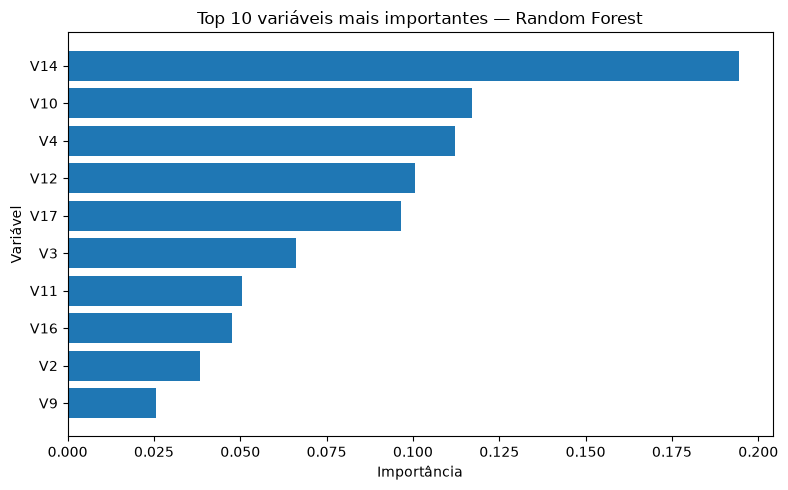

In [23]:
top_features = feature_importance.head(10).sort_values(
    by="Importância",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Variável"],
    top_features["Importância"]
)

plt.title("Top 10 variáveis mais importantes — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

## 9. Balanceamento dos dados com SMOTE

Como as transações fraudulentas representam uma parcela muito pequena do dataset, será utilizada a técnica SMOTE para equilibrar as classes no conjunto de treino.

O SMOTE cria exemplos sintéticos da classe minoritária com base em transações fraudulentas já existentes.

O balanceamento será aplicado somente nos dados de treino. O conjunto de teste continuará com a distribuição original para representar um cenário mais próximo de dados reais.

In [24]:
print("Distribuição antes do SMOTE:")
display(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nDistribuição depois do SMOTE:")
display(y_train_smote.value_counts())

Distribuição antes do SMOTE:


Class
0    199020
1       344
Name: count, dtype: int64


Distribuição depois do SMOTE:


Class
0    199020
1    199020
Name: count, dtype: int64

### Random Forest com dados balanceados

Agora será treinado um novo Random Forest usando os dados balanceados pelo SMOTE.

Diferente do modelo anterior, não será utilizado `class_weight="balanced"`, porque o próprio SMOTE já equilibrará as classes de treino.

In [25]:
random_forest_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

random_forest_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = random_forest_smote.predict(X_test)
y_prob_rf_smote = random_forest_smote.predict_proba(X_test)[:, 1]

print("Random Forest com SMOTE treinado com sucesso.")

Random Forest com SMOTE treinado com sucesso.


### Avaliação do Random Forest com SMOTE

O modelo treinado com dados balanceados será avaliado no conjunto de teste original.

Dessa forma, é possível verificar se o SMOTE ajudou a identificar mais fraudes sem tornar a quantidade de falsos positivos excessiva.

In [26]:
print("Relatório de classificação — Random Forest com SMOTE\n")

print(
    classification_report(
        y_test,
        y_pred_rf_smote,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — Random Forest com SMOTE

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.47      0.82      0.60       148

    accuracy                           1.00     85443
   macro avg       0.74      0.91      0.80     85443
weighted avg       1.00      1.00      1.00     85443



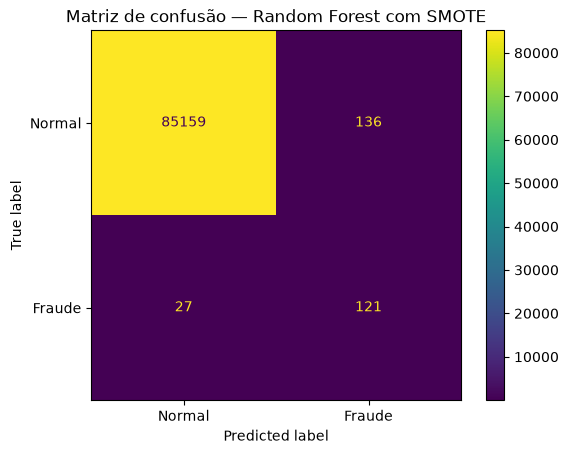

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_smote,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — Random Forest com SMOTE")
plt.show()

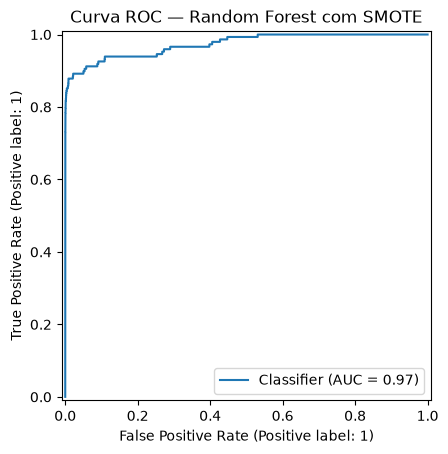

ROC-AUC do Random Forest com SMOTE: 0.9733


In [28]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_smote
)

plt.title("Curva ROC — Random Forest com SMOTE")
plt.show()

roc_auc_rf_smote = roc_auc_score(y_test, y_prob_rf_smote)

print(f"ROC-AUC do Random Forest com SMOTE: {roc_auc_rf_smote:.4f}")

## 10. Comparação parcial dos modelos

A tabela abaixo compara os modelos testados ao longo do projeto.

A análise considera principalmente a capacidade de detectar fraudes, a quantidade de fraudes não identificadas e o número de falsos positivos.

In [29]:
comparison_results_final = pd.concat(
    [
        comparison_results,
        pd.DataFrame([
            get_model_metrics(
                "Random Forest com SMOTE",
                y_pred_rf_smote,
                y_prob_rf_smote
            )
        ])
    ],
    ignore_index=True
)

comparison_results_final.round(4)

,Modelo,Precision (Fraude),Recall (Fraude),F1-score (Fraude),Fraudes detectadas,Fraudes não detectadas,Falsos positivos,ROC-AUC
0,Regressão Logística (0.50),0.8571,0.6081,0.7115,90,58,15,0.9586
1,Regressão Logística (0.30),0.7869,0.6486,0.7111,96,52,26,0.9586
2,Random Forest,0.7312,0.7905,0.7597,117,31,43,0.9784
3,Random Forest com SMOTE,0.4708,0.8176,0.5975,121,27,136,0.9733


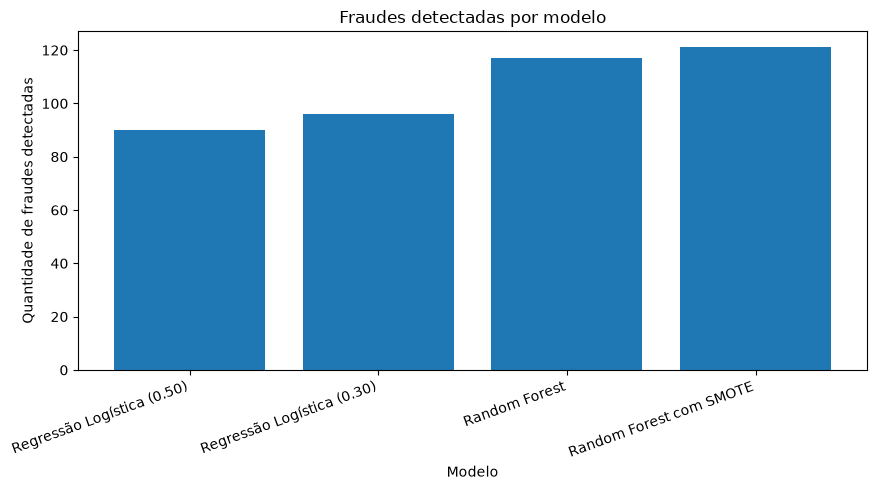

In [30]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results_final["Modelo"],
    comparison_results_final["Fraudes detectadas"]
)

plt.title("Fraudes detectadas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Quantidade de fraudes detectadas")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 11. XGBoost com balanceamento por peso

O XGBoost é um modelo de gradient boosting que cria árvores de decisão sequencialmente, tentando corrigir os erros das árvores anteriores.

Como fraudes são raras no dataset, será utilizado `scale_pos_weight` para aumentar a importância da classe fraudulenta durante o treinamento.

Diferente do SMOTE, essa abordagem não cria novos dados sintéticos. Ela altera o peso dado aos erros cometidos na classe minoritária.

In [31]:
normal_count = (y_train == 0).sum()
fraud_count = (y_train == 1).sum()

scale_pos_weight = normal_count / fraud_count

print(f"Transações normais no treino: {normal_count}")
print(f"Fraudes no treino: {fraud_count}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Transações normais no treino: 199020
Fraudes no treino: 344
scale_pos_weight: 578.55


In [32]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost treinado com sucesso.")

XGBoost treinado com sucesso.


### Avaliação do XGBoost

O XGBoost será avaliado no conjunto de teste original, que mantém a proporção real entre transações normais e fraudulentas.

Serão analisadas as métricas de precision, recall, F1-score, matriz de confusão e ROC-AUC.

In [33]:
print("Relatório de classificação — XGBoost\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — XGBoost

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.47      0.84      0.60       148

    accuracy                           1.00     85443
   macro avg       0.73      0.92      0.80     85443
weighted avg       1.00      1.00      1.00     85443



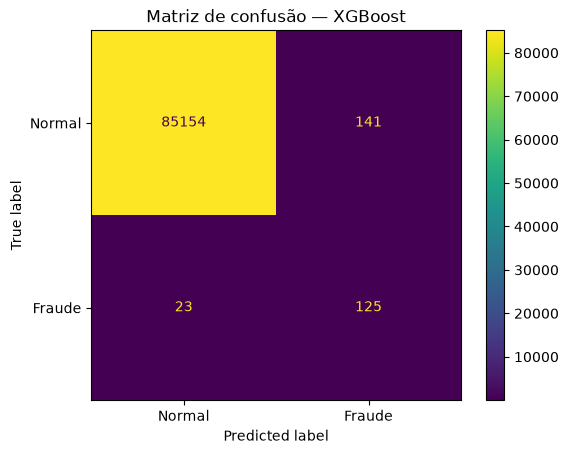

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — XGBoost")
plt.show()

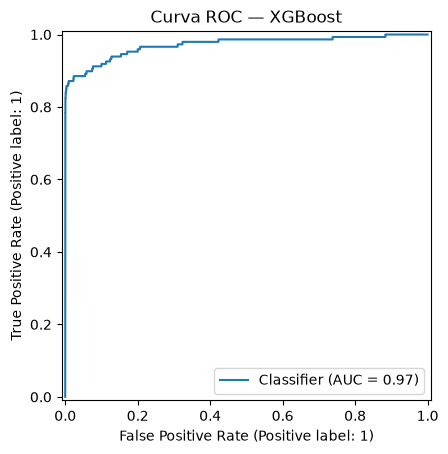

ROC-AUC do XGBoost: 0.9715


In [35]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("Curva ROC — XGBoost")
plt.show()

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"ROC-AUC do XGBoost: {roc_auc_xgb:.4f}")

In [36]:
comparison_results_final = pd.DataFrame([
    get_model_metrics(
        "Regressão Logística (0.50)",
        y_pred_logistic,
        y_prob_logistic
    ),
    get_model_metrics(
        "Regressão Logística (0.30)",
        y_pred_threshold,
        y_prob_logistic
    ),
    get_model_metrics(
        "Random Forest balanceado",
        y_pred_rf,
        y_prob_rf
    ),
    get_model_metrics(
        "Random Forest com SMOTE",
        y_pred_rf_smote,
        y_prob_rf_smote
    ),
    get_model_metrics(
        "XGBoost com pesos",
        y_pred_xgb,
        y_prob_xgb
    )
])

comparison_results_final.round(4)

,Modelo,Precision (Fraude),Recall (Fraude),F1-score (Fraude),Fraudes detectadas,Fraudes não detectadas,Falsos positivos,ROC-AUC
0,Regressão Logística (0.50),0.8571,0.6081,0.7115,90,58,15,0.9586
1,Regressão Logística (0.30),0.7869,0.6486,0.7111,96,52,26,0.9586
2,Random Forest balanceado,0.7312,0.7905,0.7597,117,31,43,0.9784
3,Random Forest com SMOTE,0.4708,0.8176,0.5975,121,27,136,0.9733
4,XGBoost com pesos,0.4699,0.8446,0.6039,125,23,141,0.9715


## 12. Importância das variáveis no XGBoost

O XGBoost também permite identificar quais variáveis tiveram maior influência nas previsões.

Como as variáveis `V1` até `V28` são anonimizadas, a análise indica apenas relevância para o modelo, sem permitir interpretar o significado real de cada variável.

In [37]:
xgb_feature_importance = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importância",
    ascending=False
)

xgb_feature_importance.head(10)

,Variável,Importância
14,V14,0.361995
4,V4,0.073637
10,V10,0.045065
20,V20,0.037844
12,V12,0.035946
8,V8,0.033874
29,Amount_log,0.030707
21,V21,0.027154
23,V23,0.026457
28,V28,0.024340


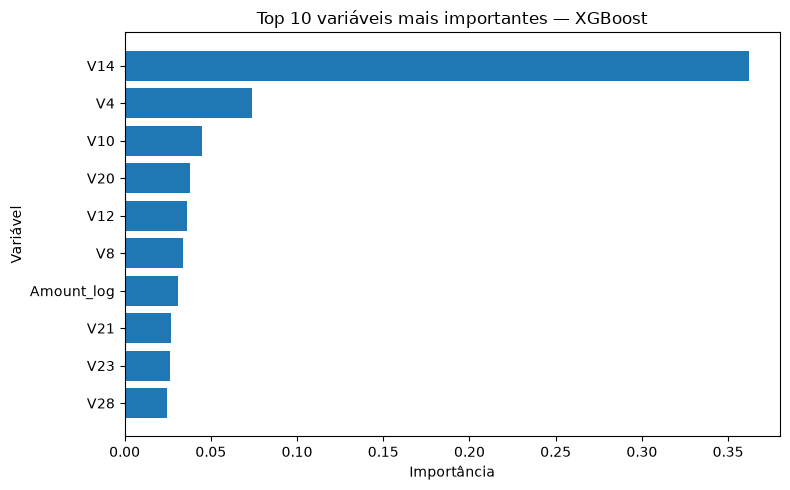

In [38]:
top_xgb_features = xgb_feature_importance.head(10).sort_values(
    by="Importância",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_xgb_features["Variável"],
    top_xgb_features["Importância"]
)

plt.title("Top 10 variáveis mais importantes — XGBoost")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

## 13. Ajuste de hiperparâmetros

Nesta etapa, será utilizado o GridSearchCV para testar combinações simples de hiperparâmetros do XGBoost.

O critério de escolha será o recall, pois o objetivo é reduzir a quantidade de fraudes não detectadas.

In [39]:
xgb_for_search = XGBClassifier(
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1
)

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_for_search,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print(f"Melhor recall médio: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores parâmetros: {'max_depth': 3, 'n_estimators': 50}
Melhor recall médio: 0.8895


## 14. Avaliação do XGBoost ajustado

Após testar combinações simples de hiperparâmetros, o melhor modelo encontrado pelo GridSearchCV será avaliado no conjunto de teste.

Essa avaliação é importante porque o conjunto de teste representa dados novos, que não participaram do treinamento nem da validação cruzada.

In [40]:
best_xgb_model = grid_search.best_estimator_

y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_prob_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Melhor XGBoost avaliado com sucesso.")

Melhor XGBoost avaliado com sucesso.


In [41]:
print("Relatório de classificação — XGBoost ajustado\n")

print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        target_names=["Normal", "Fraude"]
    )
)

Relatório de classificação — XGBoost ajustado

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     85295
      Fraude       0.12      0.86      0.20       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.60     85443
weighted avg       1.00      0.99      0.99     85443



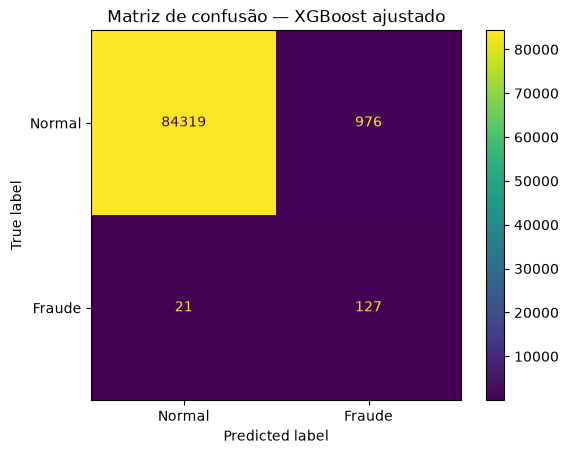

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_tuned,
    display_labels=["Normal", "Fraude"],
    values_format="d"
)

plt.title("Matriz de confusão — XGBoost ajustado")
plt.show()

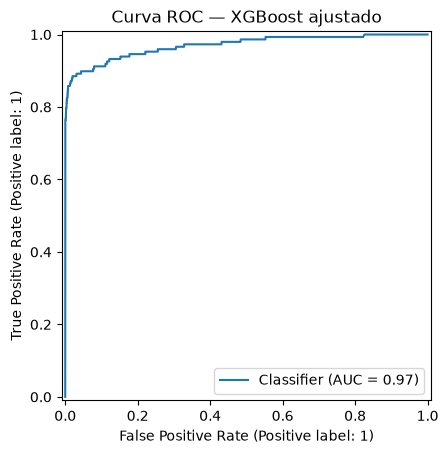

ROC-AUC do XGBoost ajustado: 0.9699


In [43]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb_tuned
)

plt.title("Curva ROC — XGBoost ajustado")
plt.show()

roc_auc_xgb_tuned = roc_auc_score(y_test, y_prob_xgb_tuned)

print(f"ROC-AUC do XGBoost ajustado: {roc_auc_xgb_tuned:.4f}")

In [44]:
comparison_results_final = pd.concat(
    [
        comparison_results_final,
        pd.DataFrame([
            get_model_metrics(
                "XGBoost ajustado",
                y_pred_xgb_tuned,
                y_prob_xgb_tuned
            )
        ])
    ],
    ignore_index=True
)

comparison_results_final.round(4)

,Modelo,Precision (Fraude),Recall (Fraude),F1-score (Fraude),Fraudes detectadas,Fraudes não detectadas,Falsos positivos,ROC-AUC
0,Regressão Logística (0.50),0.8571,0.6081,0.7115,90,58,15,0.9586
1,Regressão Logística (0.30),0.7869,0.6486,0.7111,96,52,26,0.9586
2,Random Forest balanceado,0.7312,0.7905,0.7597,117,31,43,0.9784
3,Random Forest com SMOTE,0.4708,0.8176,0.5975,121,27,136,0.9733
4,XGBoost com pesos,0.4699,0.8446,0.6039,125,23,141,0.9715
5,XGBoost ajustado,0.1151,0.8581,0.2030,127,21,976,0.9699


### Interpretação do XGBoost ajustado

O GridSearchCV foi configurado para priorizar o recall. Por isso, o XGBoost ajustado detectou mais fraudes e reduziu a quantidade de fraudes não identificadas.

Entretanto, esse ganho ocorreu com um aumento expressivo de falsos positivos. Das transações classificadas como fraude pelo modelo, apenas uma parcela pequena era realmente fraudulenta.

Esse resultado demonstra que otimizar apenas o recall não garante o melhor equilíbrio entre detecção de fraude e quantidade de alertas gerados.

## 15. Explicabilidade do modelo com SHAP

O SHAP ajuda a entender quais variáveis tiveram maior impacto nas previsões do modelo.

Neste projeto, será utilizado o XGBoost original, pois ele apresentou um resultado mais equilibrado que o XGBoost ajustado apenas para recall.

Como as variáveis `V1` até `V28` são anonimizadas, a análise indica relevância estatística para o modelo, mas não permite interpretar o significado de negócio de cada variável.

In [45]:
analysis_data = X_test.sample(n=100, random_state=42)

explainer = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(analysis_data)

print("Valores SHAP calculados com sucesso.")

Valores SHAP calculados com sucesso.


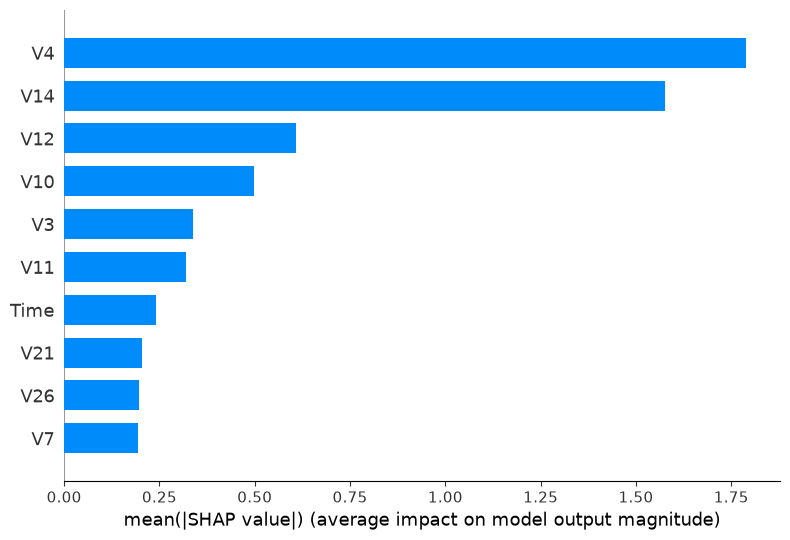

In [46]:
shap.summary_plot(
    shap_values,
    analysis_data,
    plot_type="bar",
    max_display=10
)

### Interpretação do SHAP

O gráfico SHAP mostra quais variáveis tiveram maior influência média nas previsões do modelo XGBoost.

Como as variáveis V1 até V28 são anonimizadas, não é possível determinar o significado real de cada uma delas. Ainda assim, a análise ajuda a identificar quais atributos foram mais relevantes para diferenciar transações normais e fraudulentas.

## 16. Conclusão

Este projeto analisou técnicas de machine learning para identificação de possíveis fraudes em transações financeiras.

O principal desafio encontrado foi o forte desbalanceamento do dataset: transações fraudulentas representam uma parcela muito pequena do total. Por esse motivo, a accuracy não foi utilizada como métrica principal, pois poderia apresentar um resultado alto mesmo sem detectar fraudes adequadamente.

A Regressão Logística foi utilizada como modelo baseline. Com o threshold padrão de 0,50, ela detectou 90 das 148 fraudes presentes no conjunto de teste. Ao reduzir o threshold para 0,30, o modelo passou a detectar 96 fraudes, mas também aumentou a quantidade de falsos positivos.

O Random Forest com `class_weight="balanced"` apresentou o melhor equilíbrio geral entre precision, recall, F1-score e quantidade de falsos positivos. Esse resultado indica que o modelo conseguiu identificar fraudes sem gerar um volume excessivo de alertas incorretos.

O uso de SMOTE permitiu testar uma estratégia diferente de balanceamento, criando exemplos sintéticos da classe minoritária apenas no conjunto de treino. Essa abordagem pode aumentar a capacidade de detectar fraudes, mas tende a gerar mais falsos positivos.

O XGBoost com pesos para a classe fraudulenta apresentou maior recall, detectando 125 das 148 fraudes no conjunto de teste. Já o XGBoost ajustado pelo GridSearchCV detectou 127 fraudes, reduzindo ainda mais as fraudes não identificadas. Porém, esse ganho ocorreu com um aumento expressivo de falsos positivos, mostrando que otimizar apenas o recall pode gerar um custo operacional elevado.

A análise com SHAP ajudou a identificar quais variáveis tiveram maior influência nas decisões do modelo XGBoost. Como as colunas V1 até V28 são anonimizadas, não foi possível interpretar o significado de negócio dessas variáveis, apenas sua relevância estatística para o modelo.

Em um cenário real, a escolha do modelo dependeria do custo de dois tipos de erro:

- deixar uma fraude passar sem ser detectada;
- gerar alertas falsos que precisam ser revisados manualmente.

Portanto, não existe um modelo universalmente melhor. O modelo mais adequado depende do equilíbrio desejado entre detecção de fraude, precisão dos alertas e capacidade operacional de análise.

In [47]:
comparison_results_final.to_csv(
    "comparacao_modelos.csv",
    index=False
)

print("Arquivo 'comparacao_modelos.csv' gerado com sucesso.")

Arquivo 'comparacao_modelos.csv' gerado com sucesso.
